In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from PIL import Image

Task 1

In [2]:
data = [
    "chupchungvoiae1.jpg",
    "chupchungvoiae2.jpg",
    "chupchungvoiae3.jpg",
    "chupchungvoiae4.jpg",
    "chupchungvoiae5.jpg",
    "chupchungvoiae6.jpg",
    "chupchungvoiae7.jpg",
    "chupchungvoiae8.jpg"
]

Task 1.1

In [3]:
X = []
m = len(data)
for x in data:
    tmp = np.array(Image.open("Anh/" + str(x)).convert("L"), dtype = float)
    tmp = tmp.reshape(-1)
    X.append(tmp)
X = np.array(X)
print(X.shape)
print(X)


(8, 1040400)
[[196. 196. 196. ... 201. 201. 201.]
 [157. 157. 157. ...  84.  84.  84.]
 [222. 222. 222. ... 108. 108. 108.]
 ...
 [220. 219. 217. ...  15.  15.  15.]
 [ 81.  81.  81. ... 179. 179. 179.]
 [ 85.  85.  85. ... 170. 170. 170.]]


Ở đây các ảnh đã được đồng nhất về kích thước 1020 x 1020

Khi chạy chương trình, ảnh được mã hóa thành mảng 1 chiều kích thước 1020 x 1020 = 104040, tương ứng với việc lưu giá trị của 1040400 pixel của ảnh

Hàng của ma trận X đại diện cho thông tin đã được mã hóa của 1 ảnh (có 8 hàng tương ứng 8 ảnh)

Cột của ma trận X đại diện cho dữ liệu tại vị trí pixel đó (đã được duỗi phẳng đưa về mảng 1 chiều) (có 1040400 cột tương ứng 1040400 pixel)


Task 1.2

In [4]:
m = X.mean(axis = 0)
print("Ma trận mean:")
print(m)
print("Kích thước trước khi trừ:")
print("Của mean: " + str(m.shape))
print("Của ma trận X: " + str(X.shape))
print("Ma trận X - mean:")
print(X - m)
print("Kích thước sau khi trừ:")
print("Của ma trận X - m: " + str((X - m).shape))

Ma trận mean:
[158.   157.   155.25 ... 113.5  113.5  113.5 ]
Kích thước trước khi trừ:
Của mean: (1040400,)
Của ma trận X: (8, 1040400)
Ma trận X - mean:
[[ 38.    39.    40.75 ...  87.5   87.5   87.5 ]
 [ -1.     0.     1.75 ... -29.5  -29.5  -29.5 ]
 [ 64.    65.    66.75 ...  -5.5   -5.5   -5.5 ]
 ...
 [ 62.    62.    61.75 ... -98.5  -98.5  -98.5 ]
 [-77.   -76.   -74.25 ...  65.5   65.5   65.5 ]
 [-73.   -72.   -70.25 ...  56.5   56.5   56.5 ]]
Kích thước sau khi trừ:
Của ma trận X - m: (8, 1040400)


Task 1.3

In [5]:
def cosine_similarity(X, Y = None):
    if Y is None: 
        return X
    X = X/np.linalg.norm(X, axis = 1, keepdims = True)
    Y = Y/np.linalg.norm(Y)
    return X @ Y.T

Task 1.4

In [6]:
def search(query, top_k = 3):
    sims = cosine_similarity(X, query)
    idx = np.argsort(sims)[::-1][:top_k]
    return [("chupchungvoiae" + str(i + 1), round(float(sims[i]), 3)) for i in idx]

Task 1.4

In [7]:
query = np.array(Image.open("Anh/vinh.jpg").convert("L"), dtype = float).reshape(-1)

In [8]:
results = search(query, X.shape[0])
print("Top ảnh giống query nhất:")
for name, score in results:
    print(name, score)

Top ảnh giống query nhất:
chupchungvoiae5 0.941
chupchungvoiae8 0.857
chupchungvoiae7 0.846
chupchungvoiae1 0.818
chupchungvoiae4 0.816
chupchungvoiae3 0.803
chupchungvoiae6 0.796
chupchungvoiae2 0.738


Task 1.5:
Nhận xét:
- Ảnh query với ảnh chupchungvoiae5 là giống nhau nhất, kết quả khớp với trực giác
- Ảnh query với ảnh chupchungvoiae2 là khác nhau nhất, kết quả khớp với trực giác



Task 2

Task 2.1

In [9]:
T = np.array([
    [1, 1],
    [1, 2],
    [-1, -3],
    [-3, -4],
    [4, -2],
    [3, 4],
    [4, 2]
])

In [10]:
def quay(T, theta):
    R = np.array([[np.cos(theta), - np.sin(theta)],[np.sin(theta), np.cos(theta)]])
    return T @ R

In [11]:
def cogian(T, k):
    if k == 0:
        return T
    S = np.array([[k, 0], [0, k]])
    return T @ S


In [12]:
def ve(T):
    plt.scatter(T[:, 0], T[:, 1])
    plt.axhline(y = 0)
    plt.axvline(x = 0)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.axis("equal")
    plt.show()


Trước khi thực hiện các phép biến đổi:
[[ 1  1]
 [ 1  2]
 [-1 -3]
 [-3 -4]
 [ 4 -2]
 [ 3  4]
 [ 4  2]]


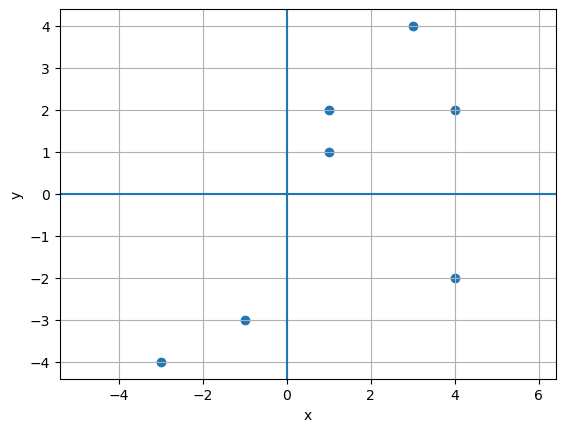

Sau khi thực hiện phép quay:
[[-0.83378017  1.14228307]
 [-1.8218118   1.29653452]
 [ 2.80984342 -1.45078597]
 [ 3.48937215 -3.58110067]
 [ 2.59306905  3.6436236 ]
 [-3.48937215  3.58110067]
 [-1.35905745  4.2606294 ]]


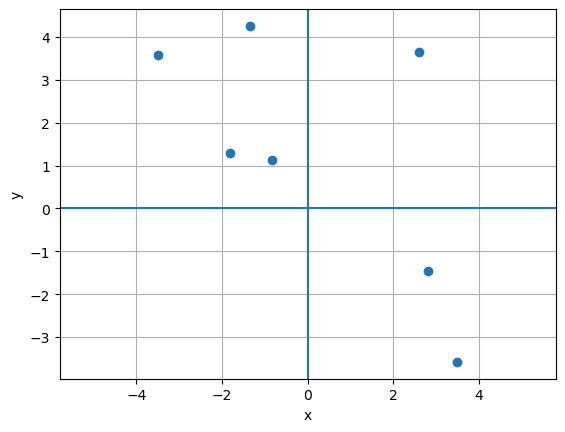

Sau khi thực hiện phép co giãn
[[ 2  2]
 [ 2  4]
 [-2 -6]
 [-6 -8]
 [ 8 -4]
 [ 6  8]
 [ 8  4]]


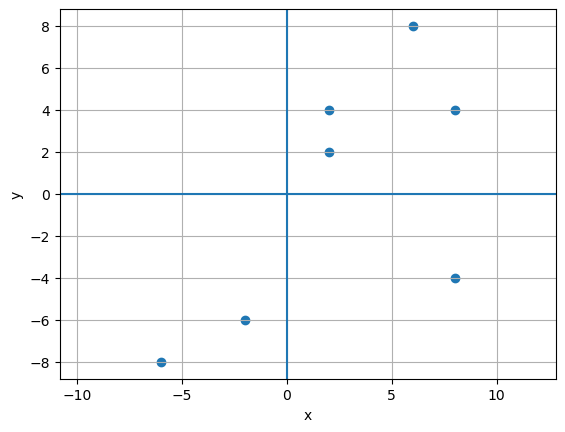

In [13]:
print("Trước khi thực hiện các phép biến đổi:")
print(T)
ve(T)
T_r = quay(T, 30)
print("Sau khi thực hiện phép quay:")
print(T_r)
ve(T_r)
print("Sau khi thực hiện phép co giãn")
T_s = cogian(T, 2)
print(T_s)
ve(T_s)

Task 1.2 + 1.3 + 1.4

In [14]:
def reconstruct(X, k):
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    m, n = X.shape
    error = np.linalg.norm(S[k:]) /np.linalg.norm(S)
    tilenen = (m * n)/(k*(m + n + 1))
    nangluongtichluy = np.sum(S[:k]**2)/np.sum(S**2)
    return ( U[:, :k] * S[:k] ) @ Vt[:k, :], tilenen, error, nangluongtichluy

In [15]:
def vedothi(K, L):
    plt.scatter(K, L)
    plt.axhline(y = 0)
    plt.axvline(x = 0)
    plt.xlabel("k")
    plt.ylabel("Giá trị")
    plt.grid(True)
    plt.show()

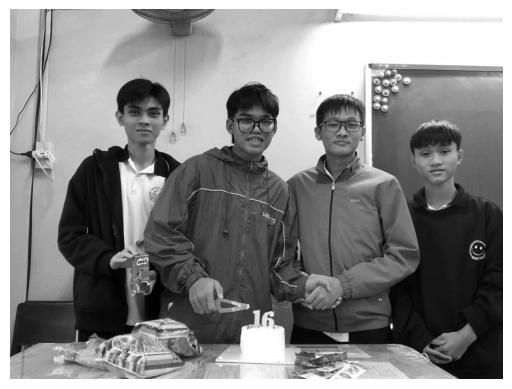

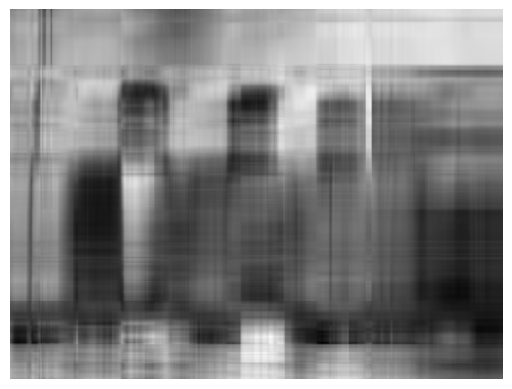

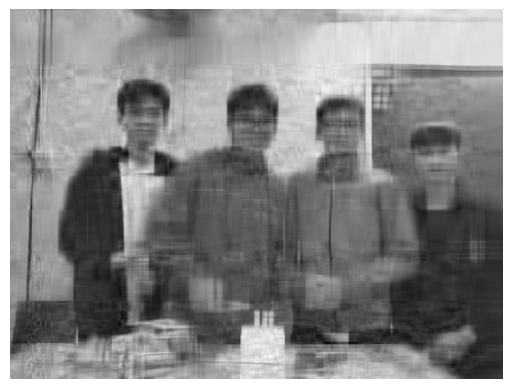

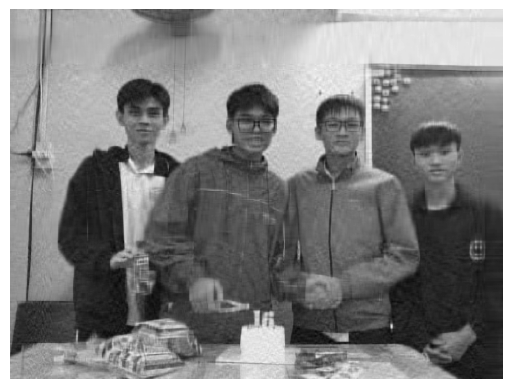

Các giá trị k:
[5, 20, 50]
Các giá trị tỉ lệ nén tương ứng:
[175.49389121338913, 43.87347280334728, 17.549389121338912]
Các giá trị sai số tương ứng:
[0.21760026458548964, 0.12284030736564139, 0.07992030925329759]
Các giá trị năng lượng tích lũy tương ứng:
[0.9526501248523246, 0.9849102588863147, 0.9936127441688573]
Đồ thị sai số:


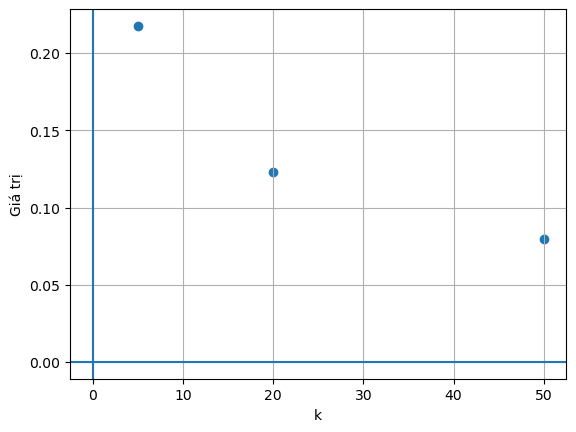

Đồ thị năng lượng tích lũy:


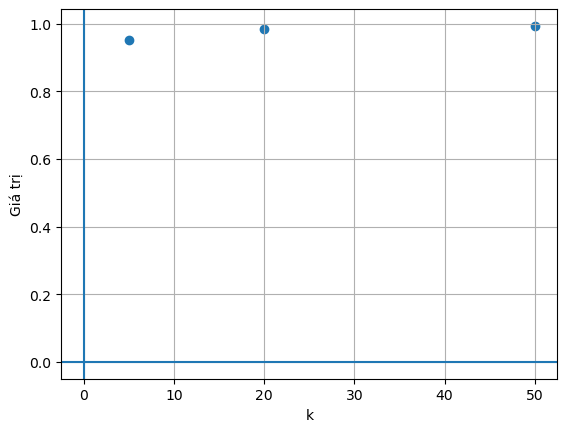

In [16]:
A = np.array(Image.open("Anh/anhlon.jpg").convert("L"), dtype=float)
plt.imshow(A, cmap="gray")
plt.axis("off")
plt.show()
list_K = [5, 20, 50]
tilenen = []
saiso = []
nangluongtichluy = []
for k in list_K:
    a, tile, sai, nangluong = reconstruct(A, k)
    tilenen.append(tile)
    saiso.append(sai)
    nangluongtichluy.append(nangluong)
    plt.imshow(a, cmap="gray")
    plt.axis("off")
    plt.show()
print("Các giá trị k:")
print(list_K)
print("Các giá trị tỉ lệ nén tương ứng:")
print(tilenen)
print("Các giá trị sai số tương ứng:")
print(saiso)
print("Các giá trị năng lượng tích lũy tương ứng:")
print(nangluongtichluy)
print("Đồ thị sai số:")
vedothi(list_K, saiso)
print("Đồ thị năng lượng tích lũy:")
vedothi(list_K, nangluongtichluy)


Ở đây may mắn thay các giá trị của k đều cho năng lượng tích lũy >= 90% nên ta có thể chọn bất kì k trong các giá trị trên cũng thỏa giữ lại ít nhất 90% thông tin của ảnh